# Smooth max for HD split

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

## Hydrostatic-deviatoric split:

Let 
\begin{align}
W^+(e) & =\tfrac{1}{2} \left(\mathbb{A}e^{S+}\cdot e^{S+} + A e^D\cdot e^D\right)\\
W^-(e) & = \tfrac12 \mathbb{A}e^{S-}\cdot e^{S-}
\end{align}
with $e^{S+} = \frac{\max(\mathrm{tr}(e), 0)}{N} \mathbf{I}$ and $e^{S-} = -\frac{\max(-\mathrm{tr}(e), 0)}{N}\mathbf{I}$ the positive and negative hydrostatic strain tensor, and $e^D = e - e^{S+} - e^{S-}$ the deviatoric strain tensor.

We can rewrite $W^+$ and $W^-$ as
\begin{align}
    W^-(e) & = \tfrac12 \max(-\mathrm{tr}(e), 0)^2 \frac{\mathbb{A}\mathbf{I}\cdot \mathbf{I}}{N^2}\\
    W^+(e) & = \frac12 \mathbb{A} e \cdot e - W^-(e).
\end{align}


Let $\phi_\gamma$ be a $C^2$ approximation of $\max(0,x)^2$. We approximate $W^+$ and $W^-$ by:
\begin{align}
W^-_\gamma(e) & = \tfrac12\phi_\gamma(-\mathrm{tr}(e)) \frac{\mathbb{A}\mathbf{I}\cdot \mathbf{I}}{N^2}\\
W^+_\gamma(e) & = \tfrac12 \mathbb{A} e \cdot e - W^-_\gamma(e)
\end{align}

We then get that:
\begin{align}
DW^-_\gamma(e)[\tilde{e}] & = -\tfrac12\phi'_\gamma(-\mathrm{tr}(e)) \frac{\mathbb{A}\mathbf{I}\cdot \mathbf{I}}{N^2} \mathrm{tr}(\tilde{e})\\
DW^+_\gamma(e)[\tilde{e}] & = \mathbb{A}e \cdot \tilde{e} - DW^-_\gamma(e)[\tilde{e}]
\end{align}
and
\begin{align}
D^2W^-_\gamma(e)[\tilde{e},\bar{e}] & = \tfrac12\phi''_\gamma(-\mathrm{tr}(e)) \frac{\mathbb{A}\mathbf{I}\cdot \mathbf{I}}{N^2} \mathrm{tr}(\tilde{e}) \mathrm{tr}(\bar{e})\\
D^2W^+_\gamma(e)[\tilde{e},\bar{e}] & = \mathbb{A}\bar{e} \cdot \tilde{e} - D^2W^-_\gamma(e)[\tilde{e},\bar{e}]
\end{align}


Note that for isotropic Hooke's laws, $\frac{\mathbb{A}\mathbf{I}\cdot \mathbf{I}}{N^2} = \kappa$.

In [21]:
def phi(x,gamma):
   if x <= -gamma / 2:
      return 0
   elif x <= gamma / 2:
      return (x + gamma / 2)**3 / 3 / gamma
   else:
      return x**2 + (gamma / 2)**2 / 3

def phip(x,gamma):
   if x <= -gamma / 2:
      return 0
   elif x <= gamma / 2:
      return (x + gamma / 2)**2 / gamma
   else:
      return 2 * x

def phipp(x,gamma):
   if x <= -gamma / 2:
      return 0
   elif x <= gamma / 2:
      return 2 * (x + gamma / 2) / gamma
   else:
      return 2


Text(0.5, 1.0, '$\\phi$')

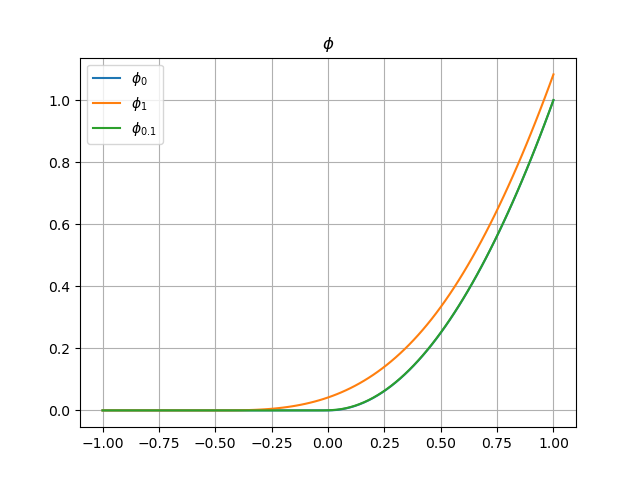

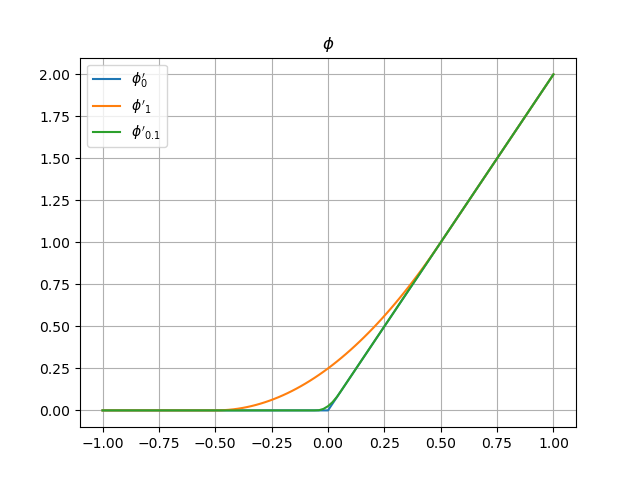

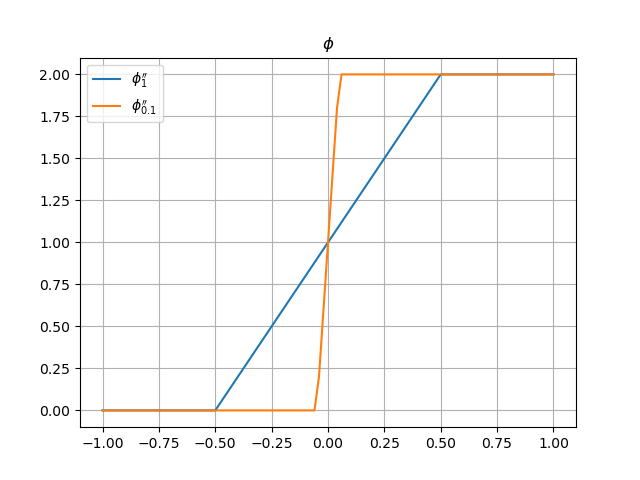

In [33]:
X = np.linspace(-1, 1, 101)
fig, ax = plt.subplots()
ax.plot(X, [max(x,0)**2 for x in X], label = r'$\phi_0$')
for gamma in (1, 0.1,):
    ax.plot(X, [phi(x, gamma) for x in X], label = fr'$\phi_{{{gamma}}}$')
ax.legend()
ax.grid()
ax.set_title(r'$\phi$')

fig, ax = plt.subplots()
ax.plot(X, [2*max(x,0) for x in X], label = r"$\phi_0'$")
for gamma in (1, 0.1,):
    ax.plot(X, [phip(x, gamma) for x in X], label = fr"$\phi'_{{{gamma}}}$")
ax.legend()
ax.grid()
ax.set_title(r'$\phi$')

fig, ax = plt.subplots()
for gamma in (1, 0.1,):
    ax.plot(X, [phipp(x, gamma) for x in X], label = fr"$\phi_{{{gamma}}}''$")
ax.legend()
ax.grid()
ax.set_title(r'$\phi$')